<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/dz_topic_12_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = "/content/drive/MyDrive/Домашнєзавдання/ML/concrete_data.csv"
df = pd.read_csv(path)

df.columns = df.columns.str.strip()

df.head()



,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


/tmp/ipykernel_18920/2629088597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Components', data=df, palette="viridis")


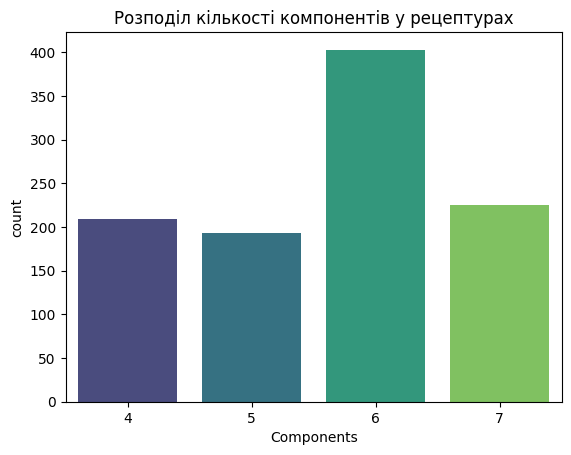

In [4]:
feature_cols = ['cement','blast_furnace_slag','fly_ash','water',
                'superplasticizer','coarse_aggregate','fine_aggregate']

df['Components'] = (df[feature_cols] > 0).sum(axis=1)

sns.countplot(x='Components', data=df, palette="viridis")
plt.title("Розподіл кількості компонентів у рецептурах")
plt.show()


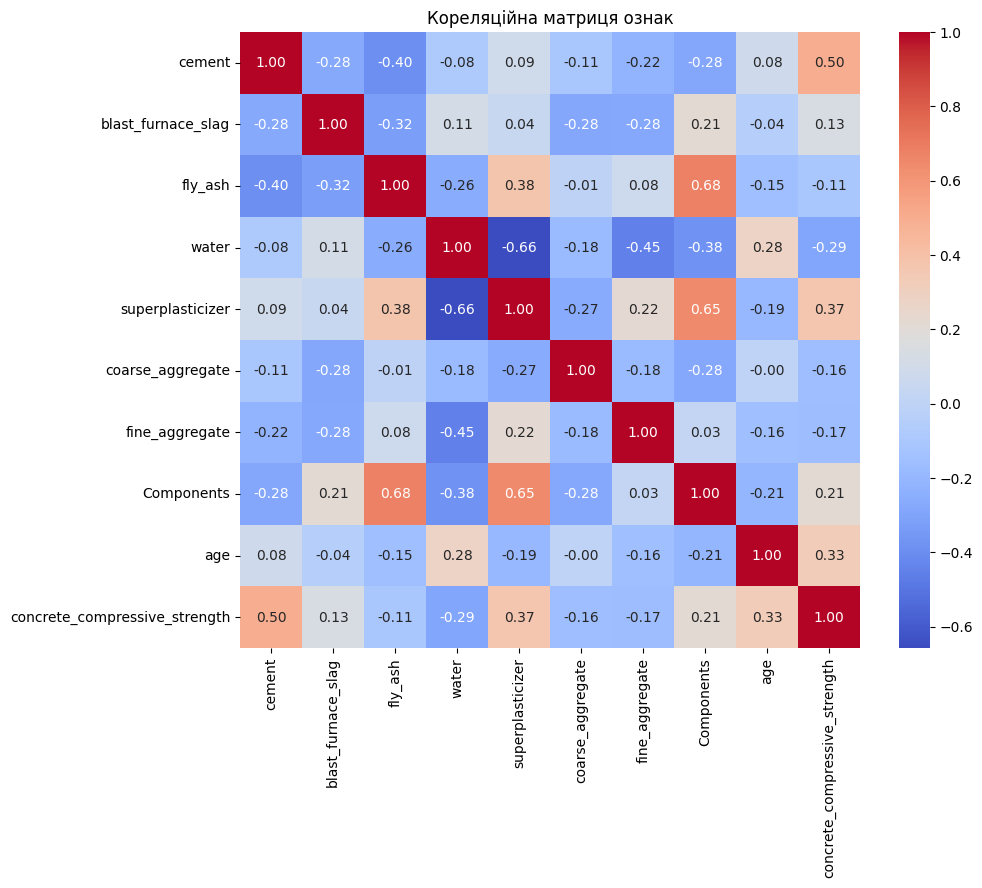

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols + ['Components','age']])

plt.figure(figsize=(10,8))
sns.heatmap(df[feature_cols + ['Components','age','concrete_compressive_strength']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляційна матриця ознак")
plt.show()


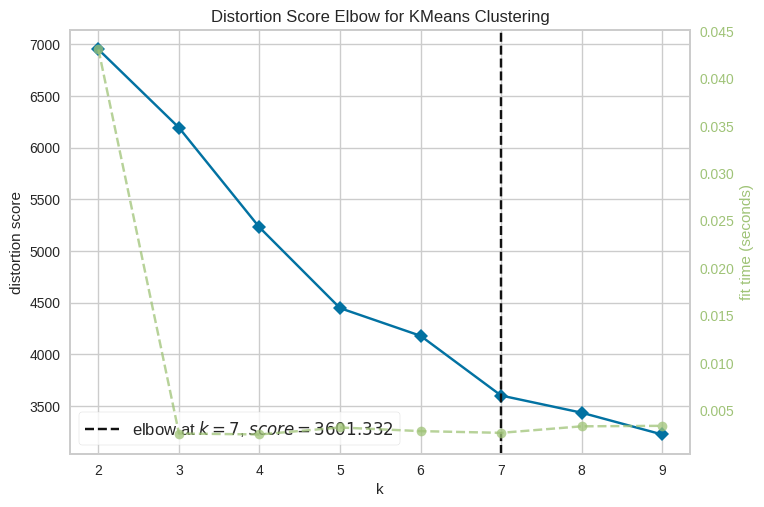

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [6]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(X_scaled)
visualizer.show()


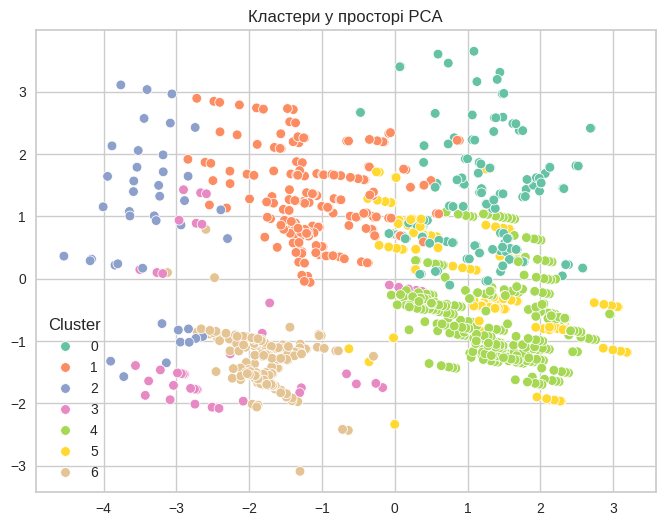

In [7]:
optimal_k = visualizer.elbow_value_
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette="Set2")
plt.title("Кластери у просторі PCA")
plt.show()


In [8]:
cluster_report = df.groupby('Cluster').median()
cluster_report['count'] = df.groupby('Cluster').size()
cluster_report


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,Components,count
Cluster,,,,,,,,,,,
0,255.15,107.8,123.0,193.0,8.50,873.55,750.0,28.0,32.945,7.0,144
1,192.00,183.9,0.0,192.0,0.00,965.40,746.4,28.0,27.980,5.0,178
2,332.50,47.5,0.0,228.0,0.00,932.00,670.0,270.0,43.355,5.0,42
3,500.00,0.0,0.0,189.0,0.00,1125.00,613.0,28.0,49.720,4.0,46
4,213.70,0.0,121.6,166.6,8.15,1014.30,792.7,28.0,33.730,6.0,292
5,387.00,117.2,0.0,160.0,11.60,931.05,803.7,28.0,55.525,6.0,152
6,331.00,0.0,0.0,192.0,0.00,1003.50,789.0,28.0,25.140,4.0,176


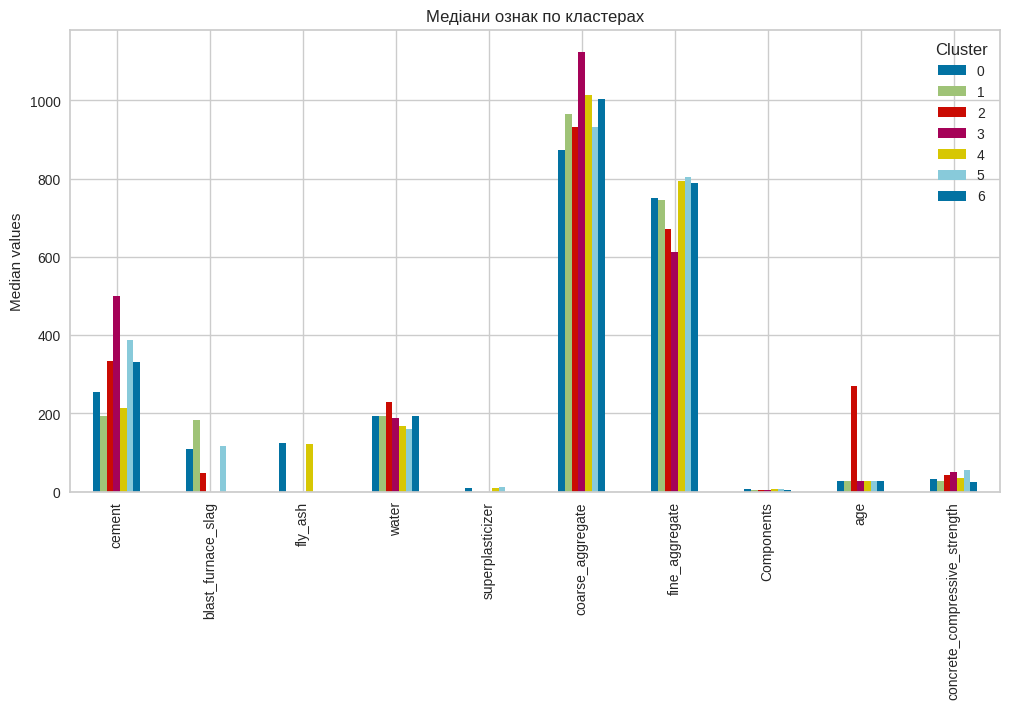

In [9]:
cluster_report[feature_cols + ['Components','age','concrete_compressive_strength']].T.plot(
    kind='bar', figsize=(12,6))
plt.title("Медіани ознак по кластерах")
plt.ylabel("Median values")
plt.show()


/tmp/ipykernel_18920/751249117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='concrete_compressive_strength', data=df, palette="Set3")


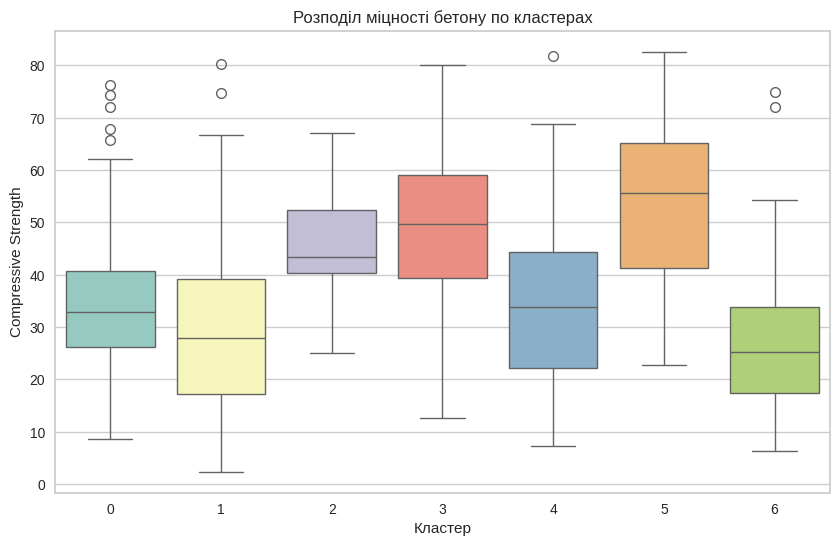

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cluster', y='concrete_compressive_strength', data=df, palette="Set3")
plt.title("Розподіл міцності бетону по кластерах")
plt.xlabel("Кластер")
plt.ylabel("Compressive Strength")
plt.show()


##Висновки
Кластеризація виділила групи рецептів бетону з різними типовими характеристиками складу.

Ознака Components показала, що багатокомпонентні рецептури мають інші профілі міцності, ніж простіші склади.

Візуалізації допомогли побачити як кластери розташовані у просторі PCA та як відрізняються медіанні значення ознак.

Це дає додаткову інформацію для подальшого дослідження факторів, що впливають на міцність бетону.